# Wine Quality

## Idea

Binary Target Transformation

Setting 'good_wine' as 1 when 'quality' is equal or bigger than 7

df['good_wine'] = (df['quality'] >= 7).astype(int)


## Setup

### Libraries

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset

In [105]:
df = pd.read_csv("../Datasets/winequality.csv")

## Data Exploration

In [106]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.1,0.875,0.05,5.7,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,3,red
1,10.3,0.170,0.47,1.4,0.037,5.0,33.0,0.99390,2.89,0.28,9.6,3,white
2,5.8,0.240,0.44,3.5,0.029,5.0,109.0,0.99130,3.53,0.43,11.7,3,white
3,6.9,0.390,0.40,4.6,0.022,5.0,19.0,0.99150,3.31,0.37,12.6,3,white
4,7.6,0.480,0.37,1.2,0.034,5.0,57.0,0.99256,3.05,0.54,10.4,3,white


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6492 entries, 0 to 6491
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6492 non-null   float64
 1   volatile acidity      6492 non-null   float64
 2   citric acid           6492 non-null   float64
 3   residual sugar        6492 non-null   float64
 4   chlorides             6492 non-null   float64
 5   free sulfur dioxide   6492 non-null   float64
 6   total sulfur dioxide  6492 non-null   float64
 7   density               6492 non-null   float64
 8   pH                    6492 non-null   float64
 9   sulphates             6492 non-null   float64
 10  alcohol               6492 non-null   float64
 11  quality               6492 non-null   int64  
 12  type                  6492 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 659.5+ KB


In [108]:
df.describe() 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000
mean,7.215149,0.339698,0.318581,5.444254,0.056056,30.523105,115.744378,0.994699,3.218432,0.531319,10.490501,5.815927
std,1.296691,0.164690,0.145348,4.758579,0.035038,17.752926,56.541478,0.002997,0.160817,0.148834,1.191985,0.869114
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,8.000000


## EDA

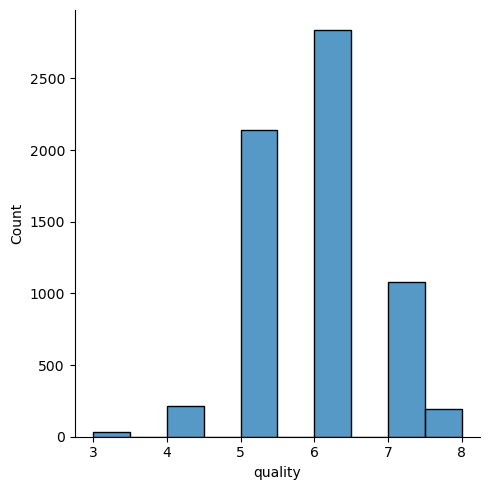

In [109]:
sns.displot(df['quality'], kde=False, bins=10)

In [110]:
df.describe(exclude=np.number) # Exclude numeric columns to get insights on categorical features

,type
count,6492
unique,2
top,white
freq,4893


What we can see here is:
- The distribution of the 'quality' variable is skewed towards lower values, with most wines being rated between 5 and 6.
- There are fewer wines rated as 'good' (quality >= 7), which may indicate that the dataset contains more average or lower-quality wines than high-quality ones. This imbalance could affect the performance of machine learning models, as they may struggle to learn from the minority class (good wines).
- The type of wine (red or white) may also play a role in the quality ratings, and it would be interesting to explore this relationship further in subsequent analyses.

In [111]:
df.nunique()

fixed acidity           106
volatile acidity        187
citric acid              89
residual sugar          316
chlorides               214
free sulfur dioxide     135
total sulfur dioxide    276
density                 996
pH                      108
sulphates               111
alcohol                 111
quality                   6
type                      2
dtype: int64

In [112]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

We can conclude with the nunique and isnull functions that there are no missing values in the dataset, and that the 'type' column has 2 unique values (red and white), while the 'quality' column has 6 unique values (3, 4, 5, 6, 7, 8).

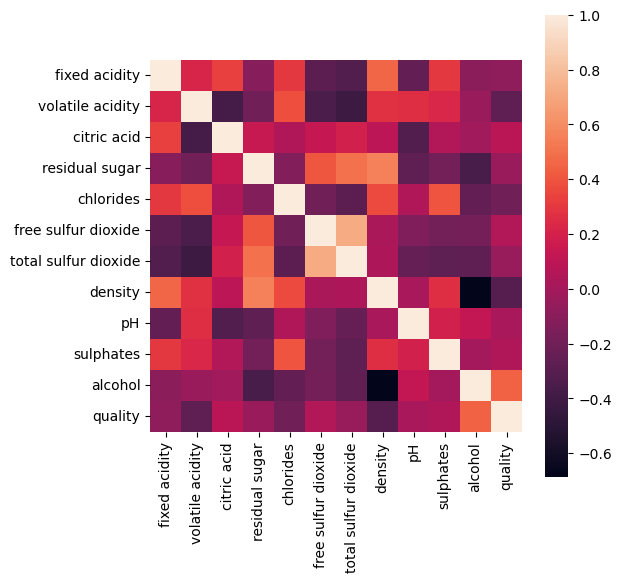

In [113]:
# Identify correlations between features and the target variable 'quality'
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True), square=True)
plt.show()

What can we conclude from the correlation heatmap?

Very strong correlation between 'alcohol' and 'quality', which suggests that higher alcohol content may be associated with better wine quality. 

Moderate positive correlation between 'sulphates' and 'quality', indicating that wines with higher sulphate levels may also be rated higher in quality.

Moderate negative correlation between 'volatile acidity' and 'quality', suggesting that wines with higher levels of volatile acidity may be rated lower in quality.


<Figure size 1000x600 with 0 Axes>

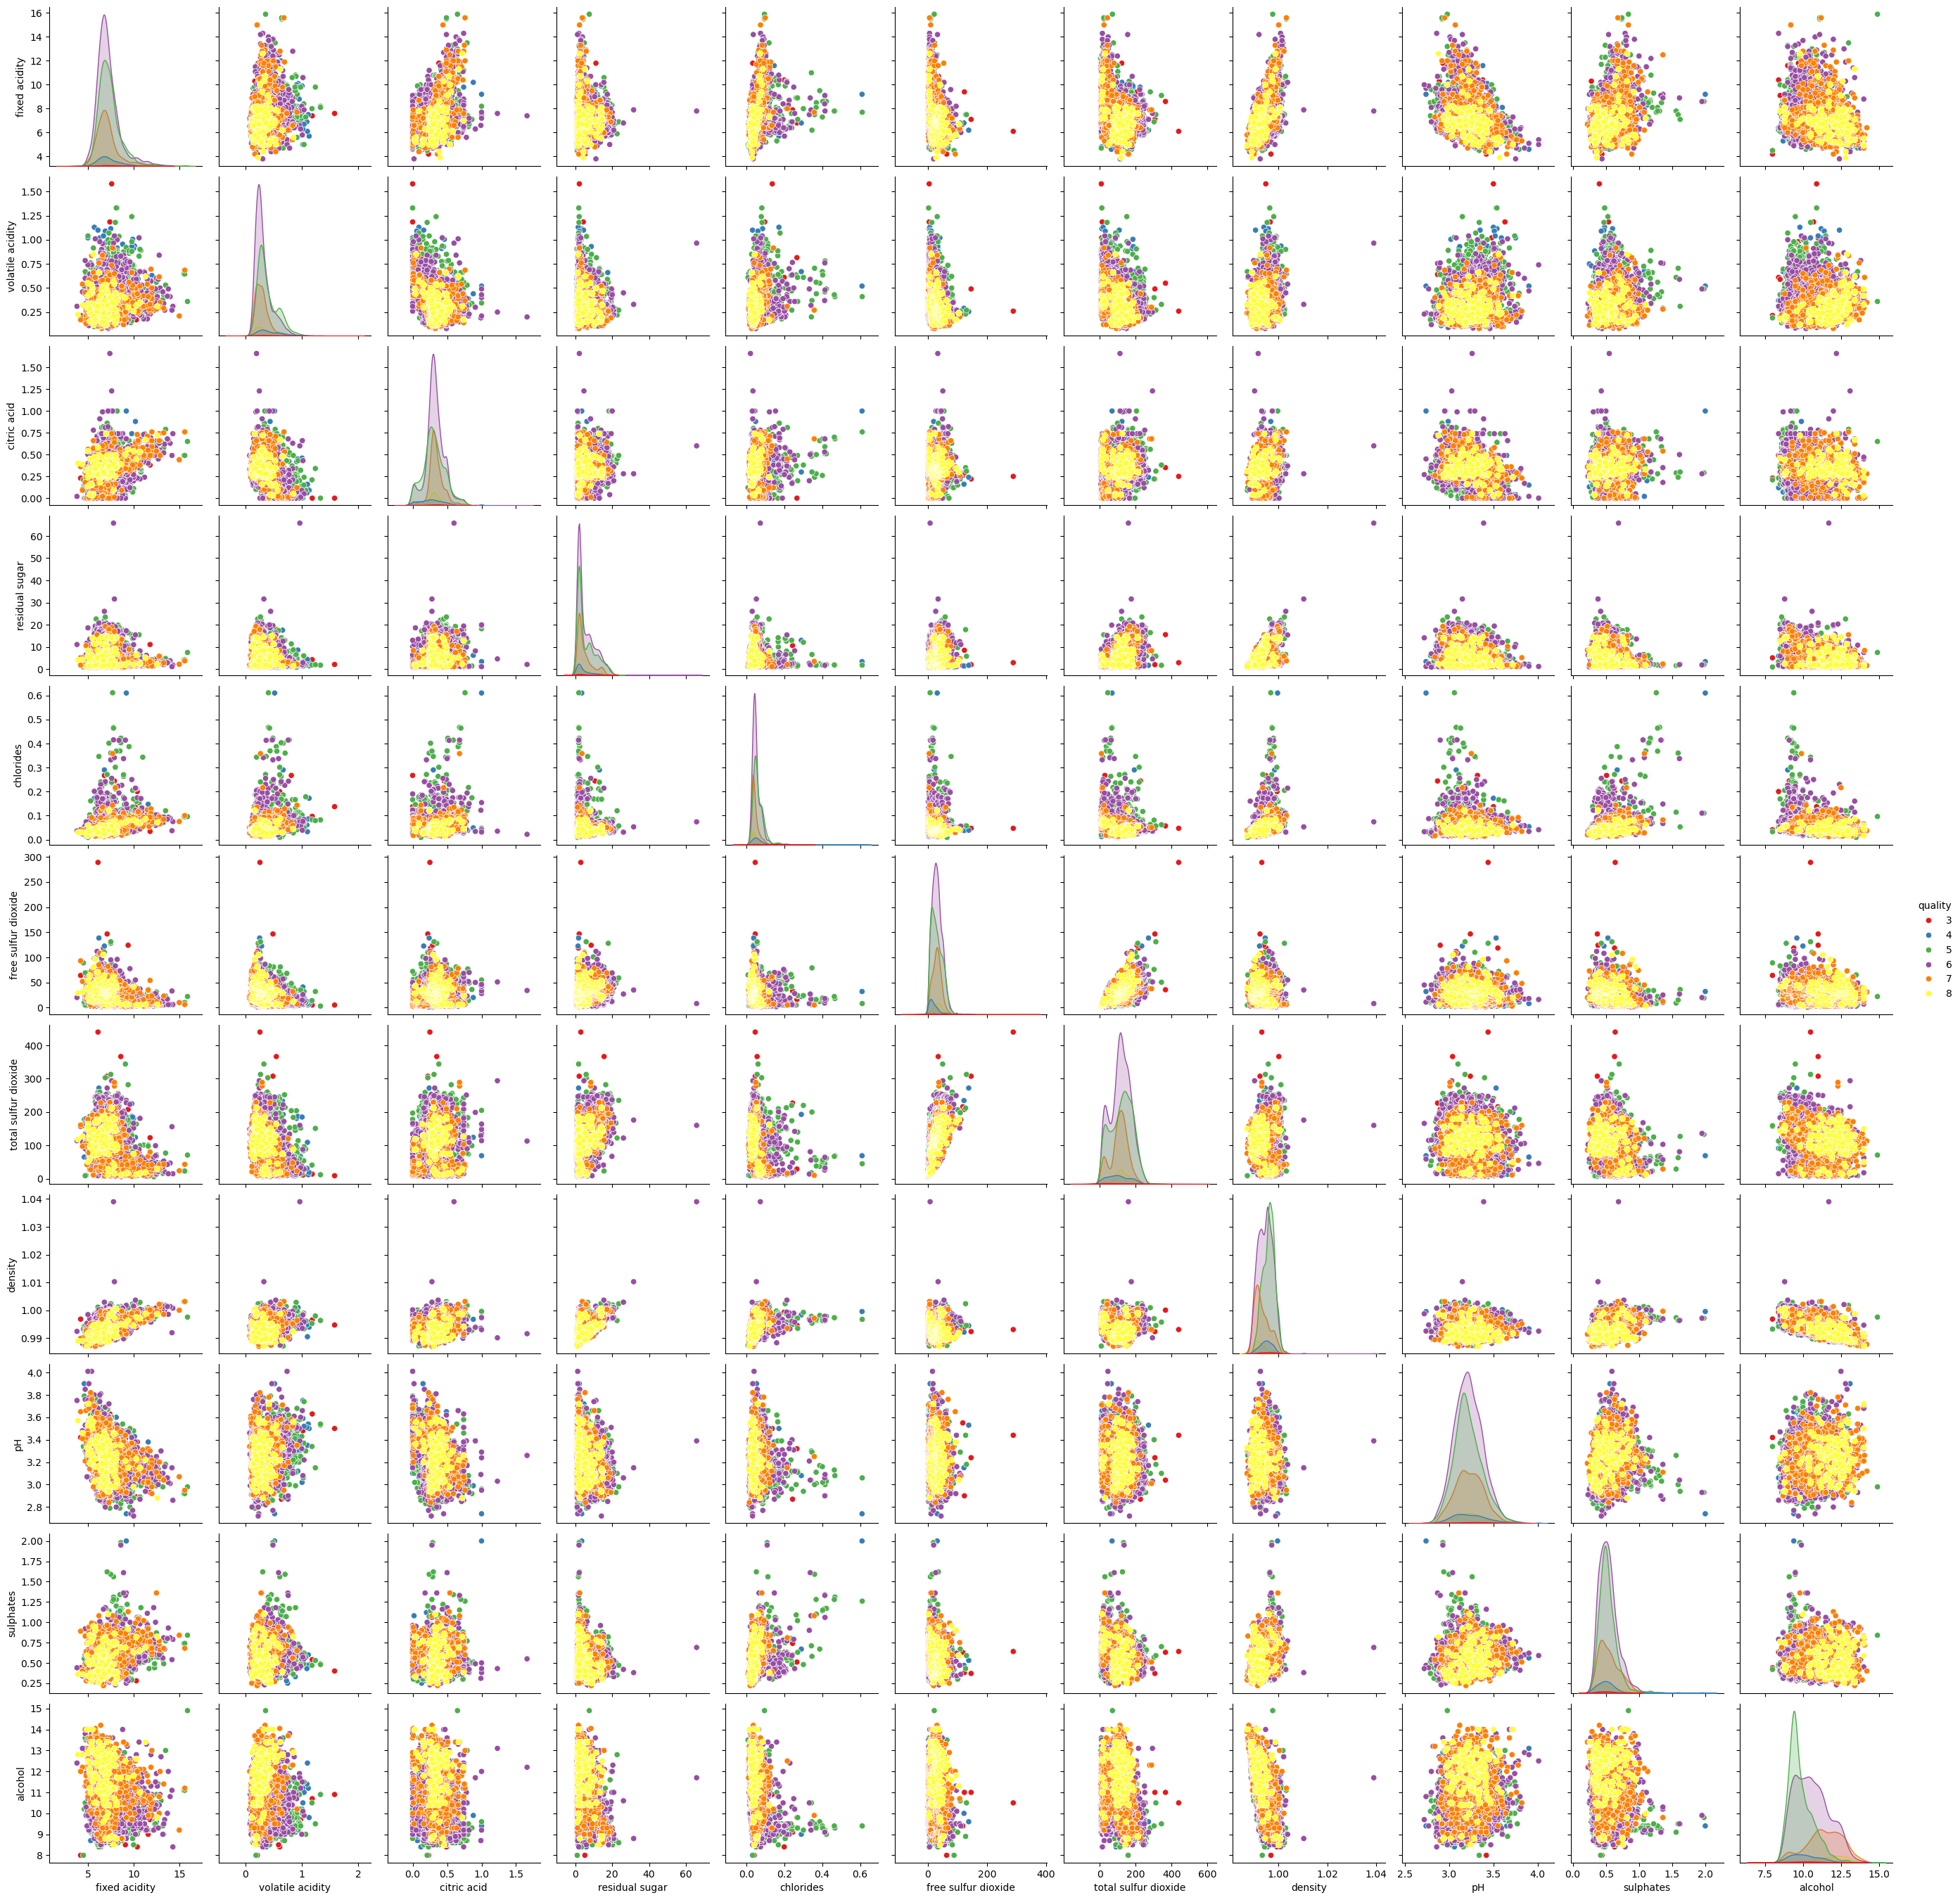

In [114]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='quality', palette='Set1')
plt.show()

In [115]:
typeCount = df['type'].value_counts()
typeCount

type
white    4893
red      1599
Name: count, dtype: int64

We can confirm the imbalance in the type of wine, with more white wines than red wines in the dataset. 

In [116]:
typeCount['red'] / df['type'].count()
typeCount['white'] / df['type'].count()
print(f"Percentage of red wines: {typeCount['red'] / df['type'].count() * 100:.2f}%")
print(f"Percentage of white wines: {typeCount['white'] / df['type'].count() * 100:.2f}%")

Percentage of red wines: 24.63%
Percentage of white wines: 75.37%


## Checking the wins type imbalance

In [117]:
# Are there more red wines or white wines in the dataset?
# And that depends in what?

# Lets separate the dataset into red and white wines, and see if there are differences in the quality distribution between them.
# And use those new datasets to see if there are differences in the correlations between features and quality for red and white wines.

white_wines = df[df['type'] == 'white']
red_wines = df[df['type'] == 'red']

Text(0.5, 1.0, 'Quality Distribution of Red Wines')

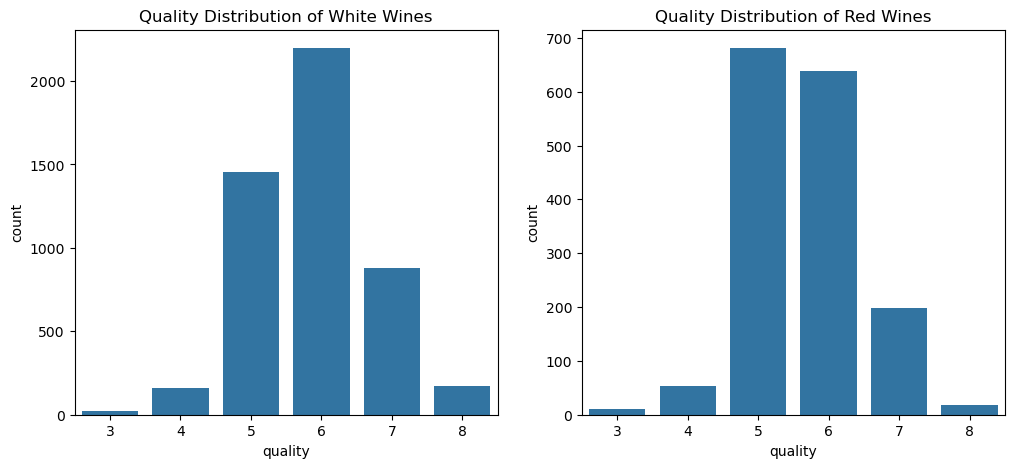

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='quality', data=white_wines, ax=axes[0])
axes[0].set_title('Quality Distribution of White Wines')

sns.countplot(x='quality', data=red_wines, ax=axes[1])
axes[1].set_title('Quality Distribution of Red Wines')

The quality distribution of white wines shows a higher concentration of wines rated 5 and 6, while red wines have a more even distribution across the quality ratings, with a noticeable number of wines rated 5, 6, and 7. This suggests that white wines in the dataset may generally be rated lower in quality compared to red wines.

Text(0.5, 1.0, 'Alcohol Content Distribution of Red Wines')

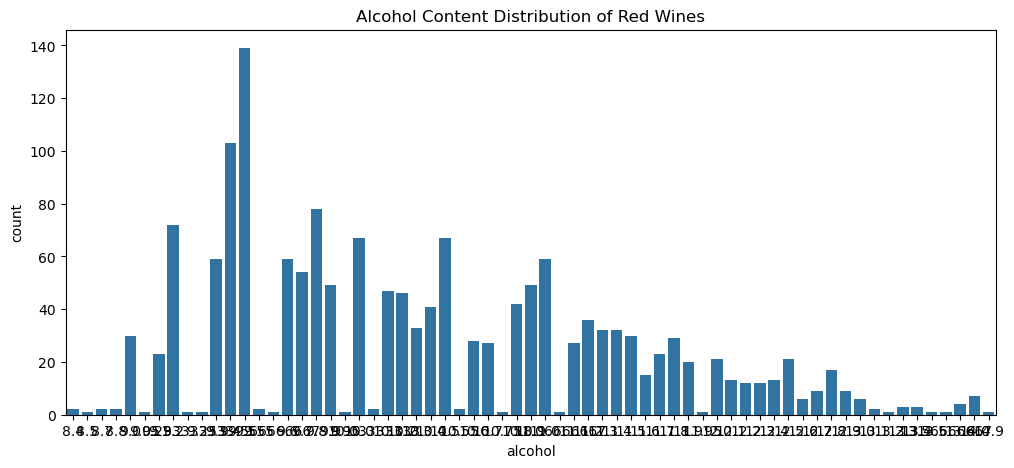

In [119]:
# Wine type counting per alcohol content range

fig, axes = plt.subplots(figsize=(12, 5))
axes = sns.countplot(x='alcohol', data=red_wines)
axes.set_title('Alcohol Content Distribution of Red Wines')


Text(0.5, 1.0, 'Alcohol Content Distribution of White Wines')

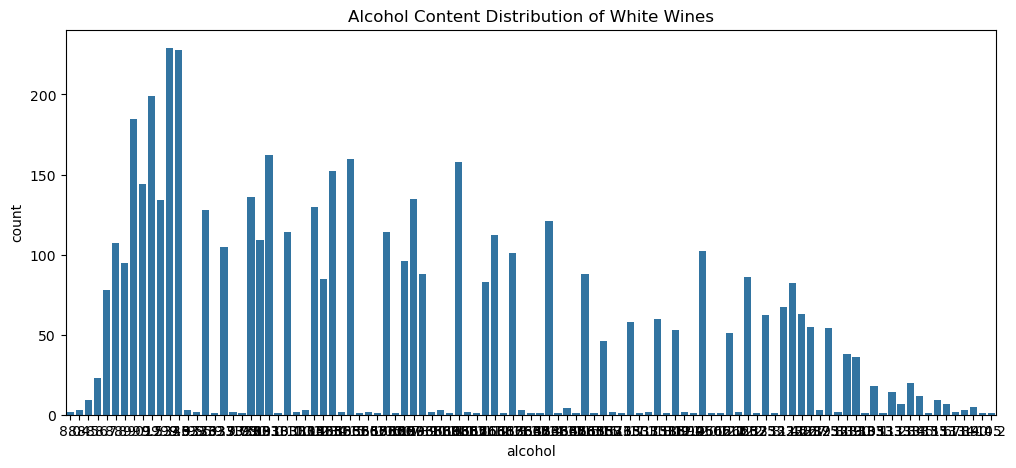

In [120]:
# Wine type counting per alcohol content range

fig, axes = plt.subplots(figsize=(12, 5))
axes = sns.countplot(x='alcohol', data=white_wines)
axes.set_title('Alcohol Content Distribution of White Wines')

Text(0.5, 1.0, 'Sulphates Content Distribution of Red Wines')

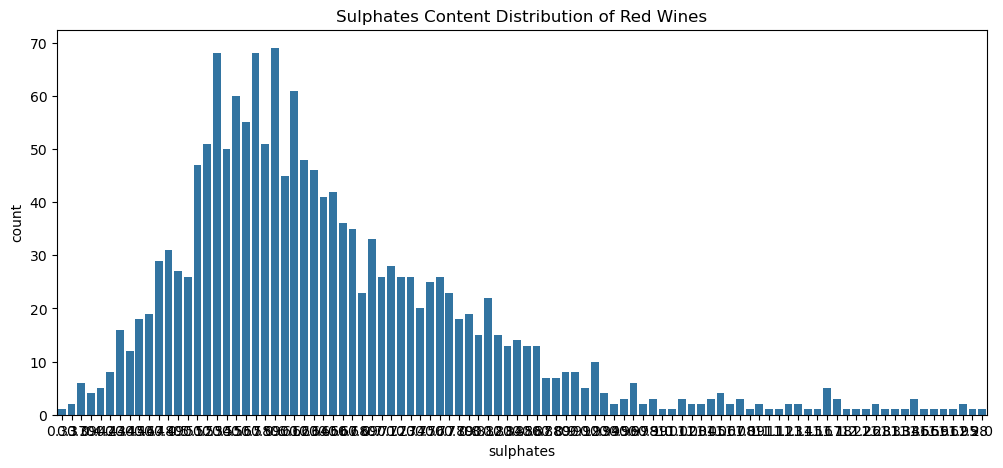

In [121]:
# Wines with higher sulphates

fig, axes = plt.subplots(figsize=(12, 5))
axes = sns.countplot(x='sulphates' , data=red_wines)
axes.set_title('Sulphates Content Distribution of Red Wines')


Text(0.5, 1.0, 'Sulphates Content Distribution of White Wines')

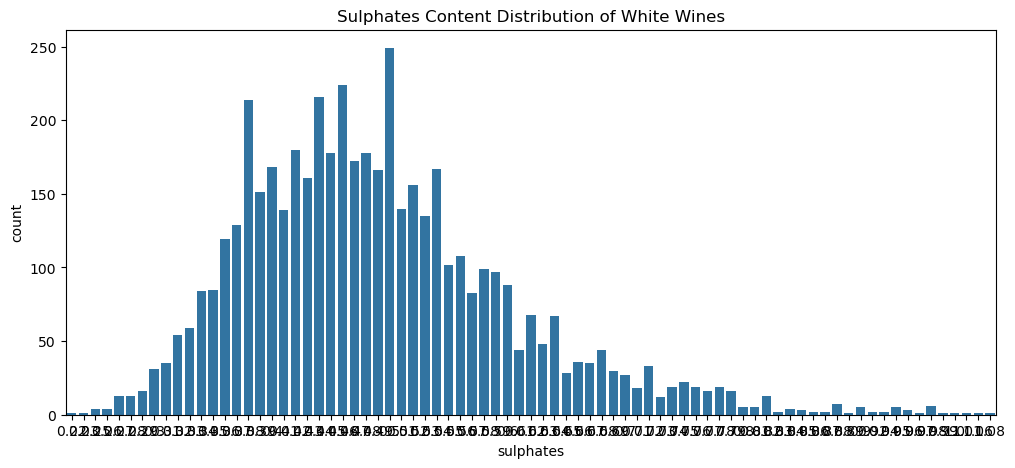

In [122]:
# Wines with higher sulphates

fig, axes = plt.subplots(figsize=(12, 5))
axes = sns.countplot(x='sulphates' , data=white_wines)
axes.set_title('Sulphates Content Distribution of White Wines')

## Preprocessing

Drop unnecessary columns and set 'good_wine' as 1 when 'quality' is equal or bigger than 7 

In [123]:
# Set good_wine as 1 when quality is equal or bigger than 7, and 0 otherwise
df['good_wine'] = (df['quality'] >= 7).astype(int)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,good_wine
0,7.1,0.875,0.05,5.70,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,3,red,0
1,10.3,0.170,0.47,1.40,0.037,5.0,33.0,0.99390,2.89,0.28,9.6,3,white,0
2,5.8,0.240,0.44,3.50,0.029,5.0,109.0,0.99130,3.53,0.43,11.7,3,white,0
3,6.9,0.390,0.40,4.60,0.022,5.0,19.0,0.99150,3.31,0.37,12.6,3,white,0
4,7.6,0.480,0.37,1.20,0.034,5.0,57.0,0.99256,3.05,0.54,10.4,3,white,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6487,5.6,0.210,0.40,1.30,0.041,81.0,147.0,0.99010,3.22,0.95,11.6,8,white,1
6488,5.8,0.170,0.34,1.80,0.045,96.0,170.0,0.99035,3.38,0.90,11.8,8,white,1
6489,5.8,0.170,0.34,1.80,0.045,96.0,170.0,0.99035,3.38,0.90,11.8,8,white,1
6490,6.7,0.240,0.30,3.85,0.042,105.0,179.0,0.99189,3.04,0.59,11.3,8,white,1


In [124]:
# Drop quality column as we will use good_wine as the target variable
df.drop('quality', axis=1, inplace=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,good_wine
0,7.1,0.875,0.05,5.7,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,red,0
1,10.3,0.170,0.47,1.4,0.037,5.0,33.0,0.99390,2.89,0.28,9.6,white,0
2,5.8,0.240,0.44,3.5,0.029,5.0,109.0,0.99130,3.53,0.43,11.7,white,0
3,6.9,0.390,0.40,4.6,0.022,5.0,19.0,0.99150,3.31,0.37,12.6,white,0
4,7.6,0.480,0.37,1.2,0.034,5.0,57.0,0.99256,3.05,0.54,10.4,white,0


In [125]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,good_wine
0,7.1,0.875,0.05,5.70,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,red,0
1,10.3,0.170,0.47,1.40,0.037,5.0,33.0,0.99390,2.89,0.28,9.6,white,0
2,5.8,0.240,0.44,3.50,0.029,5.0,109.0,0.99130,3.53,0.43,11.7,white,0
3,6.9,0.390,0.40,4.60,0.022,5.0,19.0,0.99150,3.31,0.37,12.6,white,0
4,7.6,0.480,0.37,1.20,0.034,5.0,57.0,0.99256,3.05,0.54,10.4,white,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6487,5.6,0.210,0.40,1.30,0.041,81.0,147.0,0.99010,3.22,0.95,11.6,white,1
6488,5.8,0.170,0.34,1.80,0.045,96.0,170.0,0.99035,3.38,0.90,11.8,white,1
6489,5.8,0.170,0.34,1.80,0.045,96.0,170.0,0.99035,3.38,0.90,11.8,white,1
6490,6.7,0.240,0.30,3.85,0.042,105.0,179.0,0.99189,3.04,0.59,11.3,white,1


In [126]:
# Drop unnecessary columns such as volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide
df.drop(['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'type'], axis=1, inplace=True)
df.head()

,fixed acidity,density,pH,sulphates,alcohol,good_wine
0,7.1,0.99808,3.40,0.52,10.2,0
1,10.3,0.99390,2.89,0.28,9.6,0
2,5.8,0.99130,3.53,0.43,11.7,0
3,6.9,0.99150,3.31,0.37,12.6,0
4,7.6,0.99256,3.05,0.54,10.4,0


## Split

In [128]:
y = df['good_wine']
X = df.drop(['good_wine'], axis=1)

In [129]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
y_train.sum()/y_train.count()

np.float64(0.19584055459272098)

In [131]:
y_test.sum()/y_test.count()

np.float64(0.19630484988452657)

## XGBoost Training

In [132]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [133]:
results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

def evaluate(reais, previstos):
    acc = accuracy_score(reais, previstos)
    prec = precision_score(reais, previstos)
    rec = recall_score(reais, previstos)
    f1 = f1_score(reais, previstos)
    return round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)

def print_evaluate(model, reais, previstos):
    acc, prec, rec, f1 = evaluate(reais, previstos)
    print(f"Model: {model}")
    print(f"Accuracy: {acc}")
    print(f"Precision: {prec}")
    print(f"Recall: {rec}")
    print(f"F1 Score: {f1}")
    results = np.array([model, acc, prec, rec, f1])
    results_df.loc[len(results_df)] = results

In [134]:
#pip install xgboost

In [135]:
import xgboost as xgb

In [136]:
xgb_rf = xgb.XGBClassifier(random_state=42)
xgb_rf.fit(X_train, y_train)
xgb_pred = xgb_rf.predict(X_test)
print_evaluate("XGBoost", y_test, xgb_pred)

Model: XGBoost
Accuracy: 0.8768
Precision: 0.7487
Recall: 0.5608
F1 Score: 0.6413


### Confusion Matrix 

<Axes: >

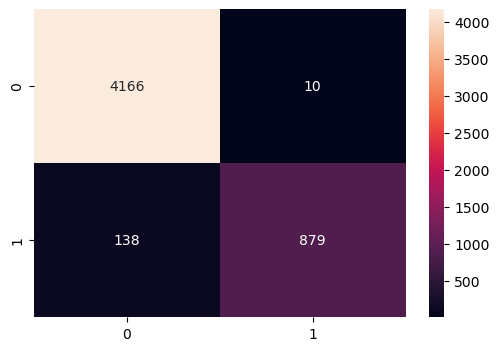

In [145]:
# Training data predictions and confusion matrix 
# Training data just for reference
train_pred = xgb_rf.predict(X_train)
cm = confusion_matrix(y_train, train_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')

<Axes: >

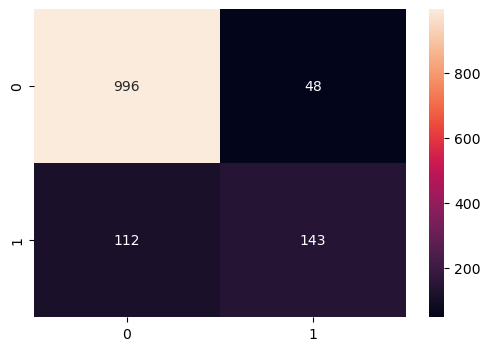

In [144]:
# Test data predictions and confusion matrix
# Test data for reference
cm_test = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d')

In [139]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.8768,0.7487,0.5608,0.6413


## XGBoost Hyperparameters

In [140]:
xgb_rf.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [141]:
from sklearn.model_selection import GridSearchCV

In [142]:
def grid_search(model, param_grid, X_train, y_train):
    grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
    grid.fit(X_train, y_train)
    print(f"Best parameters: {grid.best_params_}")
    return grid.best_estimator_
    

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2
    ]
}